In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [40]:
from src.dataset import NYUDepthDataset
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, random_split
from pathlib import Path
import torch

csv_path = Path("../data/nyu2_train_subset.csv")

transform_img = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

transform_depth = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    ])

dataset = NYUDepthDataset(csv_path, transform_img=transform_img, transform_depth=transform_depth)

img, depth = dataset[41]

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


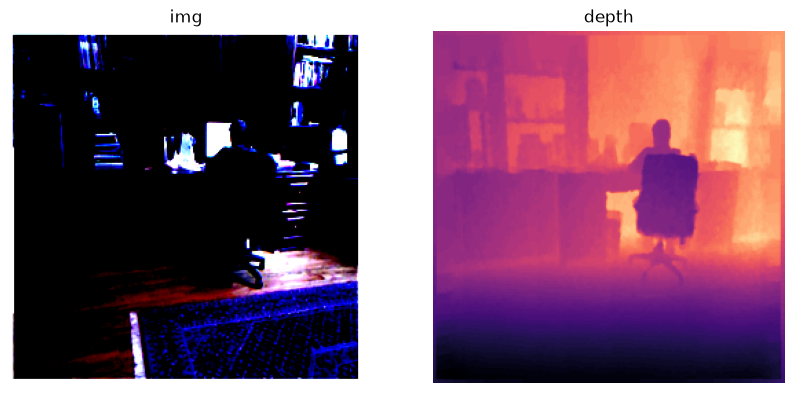

In [37]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("img")
plt.imshow(img.permute(1, 2, 0).detach().numpy())
plt.axis(False);

plt.subplot(1, 2, 2)

plt.imshow(depth.permute(1, 2, 0).detach().numpy(), cmap="magma")
plt.title("depth")
plt.axis(False);